In [1]:
import glob
import os

import tifffile as tiff
from scipy import ndimage as ndi
from skimage import morphology
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx


In [2]:
def test():
    input = r"C:\Users\morit\Desktop\work\study\Watershed\Data\Input\20260313_test\label_map_1_annotate.tif"
    frames = tiff.imread(input)
    frame = frames[100]
    structure = ndi.generate_binary_structure(rank=2, connectivity=2)
    labels, labels_number = ndi.label(frame, structure=structure)
    tiff.imwrite(r"C:\Users\morit\Desktop\work\study\Watershed\Data\output\20260606\test.tif", labels.astype(np.uint16), dtype=np.uint16)



In [3]:
# グラフ以外の処理
def load_volume(input_path: str):
    return tiff.imread(input_path)


            red edge: (23, 1) to (22, 1)
            red edge: (22, 1) to (21, 1)
            red edge: (6, 9) to (5, 7)
            red edge: (21, 1) to (20, 1)
            red edge: (5, 5) to (4, 6)
            red edge: (7, 6) to (6, 6)
            red edge: (19, 1) to (18, 1)
            red edge: (19, 2) to (18, 3)
            red edge: (10, 1) to (9, 1)
            red edge: (5, 1) to (4, 1)
            red edge: (4, 5) to (3, 3)
            red edge: (5, 7) to (4, 10)


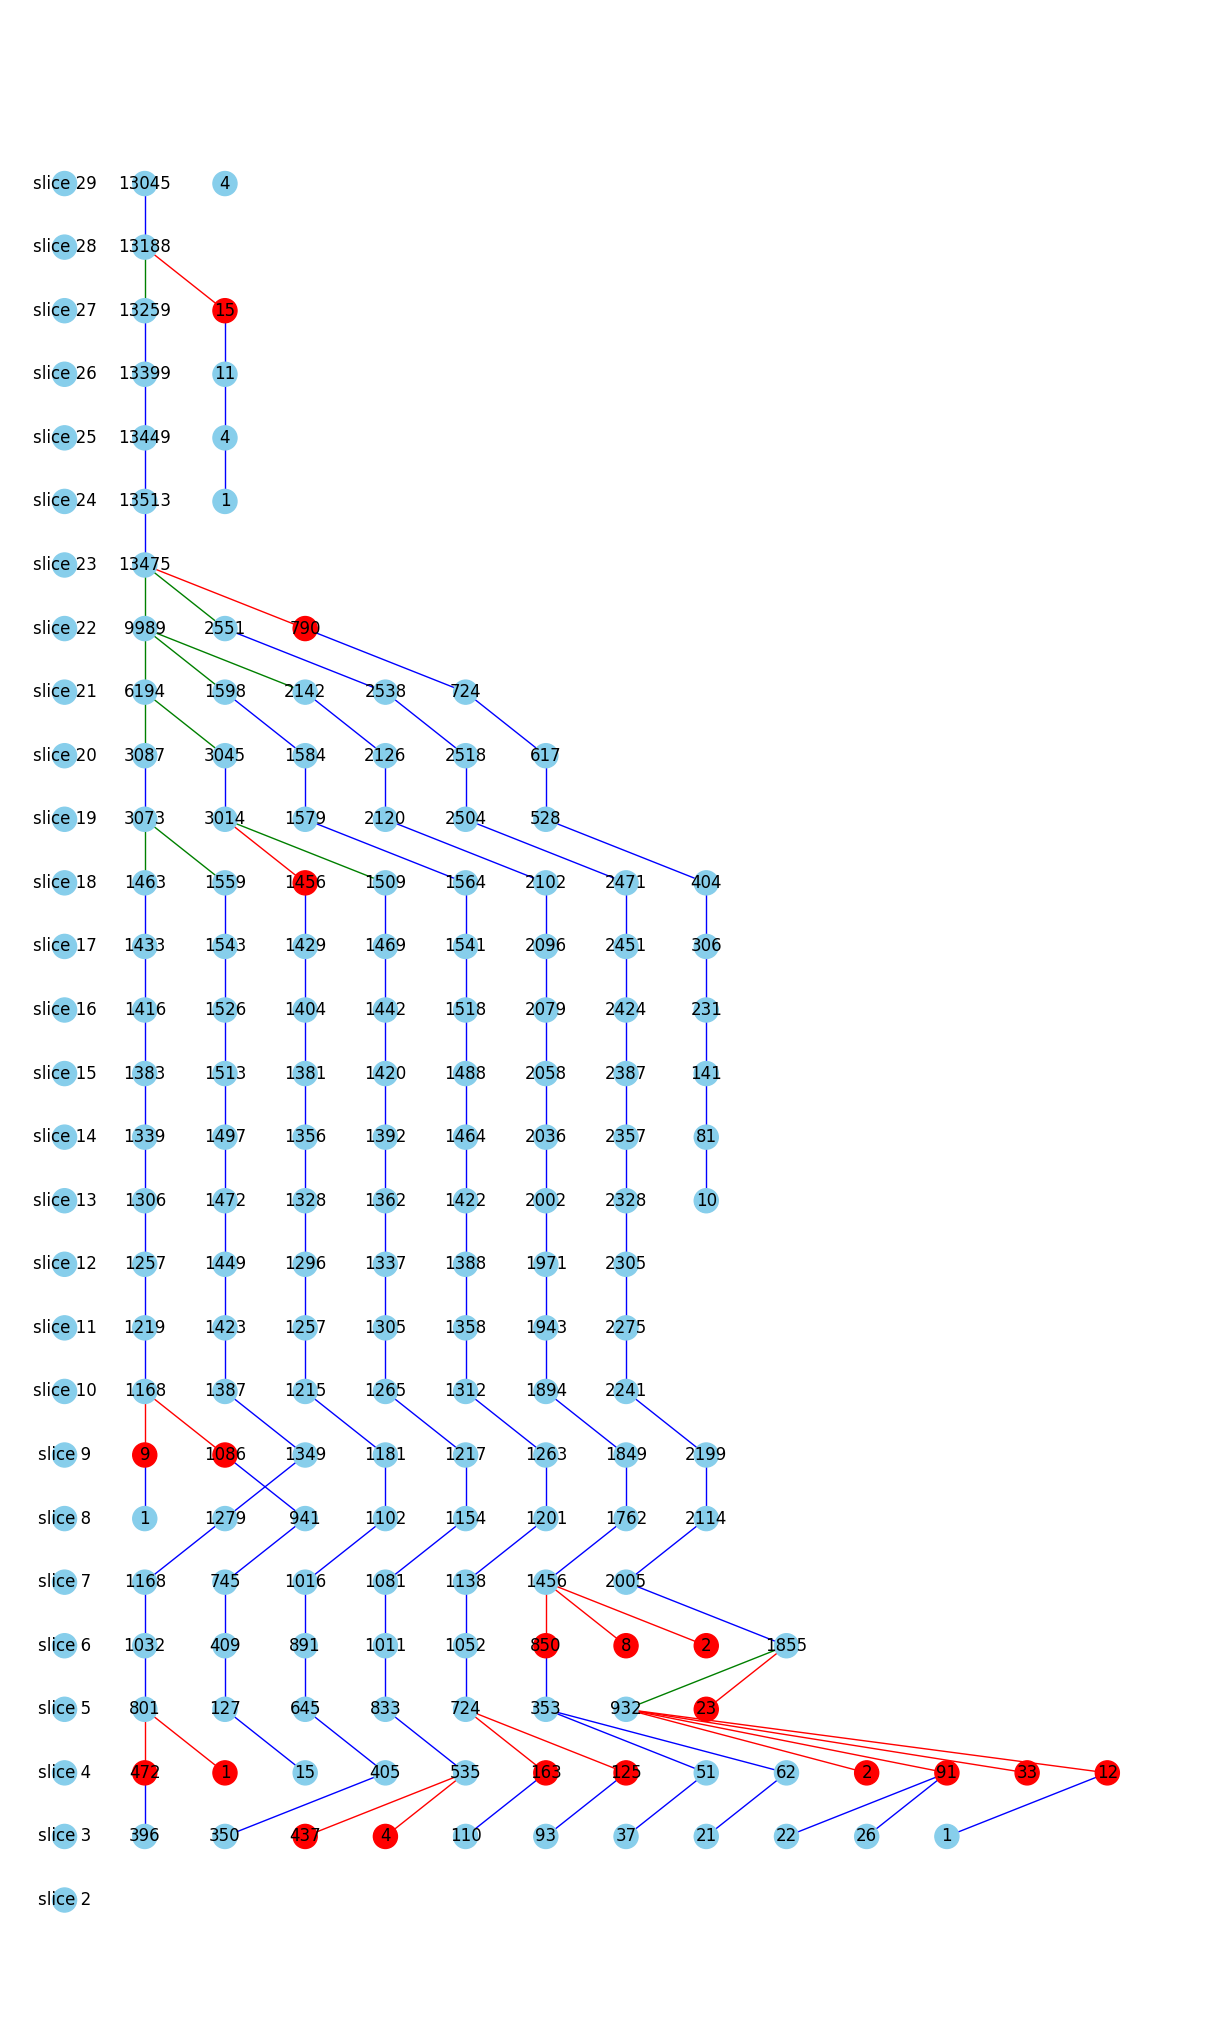

In [4]:
# 重み付きグラフの作成
def create_graph(volume: int, threshold: int, labels_connectivity: int =2):
    G = nx.Graph()
    for index, curr_slice in enumerate(volume):
        # スライスは1始まりにする
        slice_index = index + 1
        debug = True
        if debug and (slice_index >= 30):
            continue
        structure = ndi.generate_binary_structure(rank=2, connectivity=labels_connectivity)
        labels, labels_number = ndi.label(curr_slice, structure=structure)
        for label_number in range(1, labels_number+1):
            label_area = np.sum(labels == label_number)
            # 面積が重み
            G.add_node((slice_index, label_number), area = label_area, seed = False)
        if slice_index == 1:
            continue
        # 直前のスライス
        prev_slice = volume[index-1]
        prev_labels, prev_labels_number = ndi.label(prev_slice, structure=structure)
        # 重なりが0でない場所にエッジを引く
        for label_number in range(1, labels_number+1):
            overlap_label_numbers = np.unique(prev_labels[labels == label_number])
            overlap_label_numbers = overlap_label_numbers[overlap_label_numbers != 0]
            # overlap_label_numbers >= 2: 重なりが2つかつ下位ノード2つが閾値以上ならエッジを引かない
            
            edge_color = "red" # まともなエッジは青
            for overlap_label_number in overlap_label_numbers:
                 # len が 1 以下か、閾値以下のノードが一つでもあればまとも扱い
                if len(overlap_label_numbers) <= 1 or \
                    threshold > G.nodes[(slice_index, label_number)]["area"]:
                    # すべて閾値以上ならエッジは赤
                    edge_color = "blue" # 切断候補は赤
                    break
            for overlap_label_number in overlap_label_numbers:
                overlap_label_number = int(overlap_label_number)
                if ((slice_index, label_number) in G)\
                and ((slice_index-1, overlap_label_number)) in G:
                    G.add_edge(
                        (slice_index, label_number), 
                        (slice_index-1, overlap_label_number),
                        color = edge_color
                    )
                else:
                    # debug で最下層のノードはエッジが引けないため
                    # print(f"    Not Exists: {(slice_index, label_number)} or {(slice_index-1, overlap_label_number)}")
                    continue
        
            
        # エッジ削除
        # slice_index-1 の接続を見て、つながっているノード(slice_index) 

        # 表示用
        G.add_node((slice_index, 'slice_index'), seed=False)
    return G

def remove_edge(G: nx):
    # 赤いエッジでそれ以下のsliceに赤エッジがあれば緑にする
    # 赤エッジのslice以下の隣接エッジで
    # print("remove edge")
    count = 0
    for previous_node, current_node, attr in \
        sorted(G.edges(data=True),\
                key=lambda e: max(e[0][0], e[1][0]),\
                reverse=True):
        if attr.get("color") == "red":
            # print(f"find red edge: {previous_node} --- {current_node}")
            if (find_red_edge_previous_node(G, previous_node)):
                # 赤いエッジがあったので保留
                G.edges[current_node, previous_node]["color"] = "green"
            else:
                # 赤いエッジがないので切断する
                # G.remove_edge(current_node, previous_node)
                # 切断時の下位ノードをseedとする
                G.nodes[previous_node]["seed"] = True
                continue


def red_descendants_with_edges(G, start_node):
    print(f"start node: {start_node}")
    visited = set()
    stack = [start_node]

    descendant_nodes = set()
    descendant_edges = []
    while stack:
        node = stack.pop()
        if node in visited:
            continue
        visited.add(node)
        print(list(G.neighbors(node)))
        for neighbor in G.neighbors(node):
            # 子方向のみ
            if neighbor[0] <= node[0]:
                continue
            # 赤エッジのみ
            if G[node][neighbor].get("color") != "red":
                continue
            descendant_nodes.add(neighbor)
            descendant_edges.append((node, neighbor))
            stack.append(neighbor)
    return descendant_nodes, descendant_edges

def find_red_edge_previous_node(G, start_node):
    # start_node 以下の隣接スライスで赤エッジがないか判定する
    # return true: 赤エッジない -> こいつが seed
    visited = set() # 探索済みのノード
    stack = [start_node]

    descendant_nodes = set()
    descendant_edges = []
    while stack:
        node = stack.pop()
        if node in visited:
            continue
        visited.add(node) # 探索済みノードに加える
        for neighbor_node in G.neighbors(node):
            # 子ノードのみ(slice_indexが小さい)探索
            if neighbor_node[0] > node[0]:
                continue
            # 赤エッジの有無を判定
            if G[node][neighbor_node].get("color") == "red":
                print(f"            red edge: {node} to {neighbor_node}")
                return True
            # 下の層へ進むため、 neighbor_node を stack に入れる
            stack.append(neighbor_node)
    # 赤エッジが存在しないならfalse: 切断しない
    return False

def plot_graph(G: nx):
        # --- 描画 ---
    pos = {}
    for node in G.nodes:
        slice_index, label = node
        if label == 'slice_index':
            pos[node] = (0, slice_index) # 左端
        else:
            pos[node] = (label, slice_index) # x:スライス順, y:ラベル番号で上下にずらす
    plt.figure(figsize=(12, 20))
    labels = {}
    for node in G.nodes:
        if node[1] == 'slice_index':
            labels[node] = f"slice {node[0]}"
        else:
            labels[node] = f"{G.nodes[node]['area']}"
            continue
    node_colors = []
    for node in G.nodes:
        if G.nodes[node].get("seed", True):
            node_colors.append("red")
        else:
            node_colors.append('skyblue')
    edge_colors = [
        G[u][v].get("color", "black")
        for u, v in G.edges
    ]

    nx.draw(G, pos=pos, 
            with_labels=True, 
            labels=labels, 
            node_color=node_colors,
            edge_color=edge_colors)
                

if __name__ == "__main__":
    
    input_path = r"D:\_study\ImageProcessing\study\Watershed\Data\Input\20260421_filled255_No1\label_map_1_filled.tif"
    volume = load_volume(input_path)
    G = create_graph(volume, 500)
    remove_edge(G)
    plot_graph(G)
